# Attention analysis for object-token PathFormer

This notebook is the object-token counterpart to `attention_analysis.ipynb`.

The key difference is that the environmental context is no longer compressed into 4 learned prompt tokens only. Instead, each selected building is represented as its own token, so decoder cross-attention can be inspected at the **object level**.

## What is realistically interpretable here?

1. **Decoder self-attention over path history**
   - As before, we can inspect whether later generated paths rely on the first or dominant earlier path.

2. **Decoder cross-attention to individual building tokens**
   - For each predicted path step, we can inspect which building objects receive the highest attention.
   - This is much more interpretable than the compressed 4-token corridor summary.

3. **Aggregate attention trends over many validation users**
   - Do early predicted paths focus on corridor-near buildings?
   - Does attention become more diffuse for later paths?
   - Do seen vs unseen scenarios produce different concentration patterns?

## Practical caution

Attention is still **suggestive, not causal**. The safest paper claim is that the observed patterns are *consistent with* physically meaningful object selection, not that attention alone proves causal use of a building.

In [1]:
import os
import types
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

os.chdir('/home/blessedg/Pathformer')
warnings.filterwarnings('ignore', category=UserWarning)

import deepmimo as dm
from dataset.dataloaders import PreTrainMySeqDataLoader
from multiscenario_direct_training_first_step_residual import load_best_checkpoint
from multiscenario_direct_training_first_step_residual_corridor_object_tokens import (
    FirstStepResidualObjectTokenDecoder,
    ObjectTokenResidualDataset,
    build_first_step_assignments_with_object_tokens,
)
from scene_object_token_utils import SceneObjectTokenBank
from attention_object_token_plot_utils import plot_spatial_attention_map_with_scene

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_ROOT = Path('/home/blessedg/Pathformer')
PROJECT_ROOT

PosixPath('/home/blessedg/Pathformer')

## Configuration

The default configuration below points to the new per-scenario object-token checkpoint directory. This notebook is most useful once a scenario checkpoint has been trained.

Suggested uses:
- Start with a **seen** scenario such as `city_23_beijing_3p5` for clean qualitative patterns.
- Then compare against an **unseen** scenario once you have an object-token checkpoint there.
- For the paper, the most defensible figures are usually:
  - one representative single-sample heatmap
  - one aggregate plot over many validation users

In [2]:
SCENARIO = 'city_23_beijing_3p5'
SPLIT = 'val'   # 'train' or 'val'
SAMPLE_INDEX = 0
MAX_AGGREGATE_SAMPLES = 64

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / 'checkpoints_first_step_residual_corridor_object_tokens'
    / f'first_step_residual_corridor_object_tokens_{SCENARIO}_best_model_checkpoint.pth'
)

MODEL_CONFIG = {
    'hidden_dim': 512,
    'n_layers': 8,
    'n_heads': 8,
    'n_clusters': 25,
    'use_material_features': True,
    'max_objects': 24,
    'nearest_rx_k': 8,
    'nearest_tx_k': 4,
    'corridor_object_k': 12,
}

print('checkpoint:', CHECKPOINT_PATH)
print('scenario:', SCENARIO)
print('split:', SPLIT)

checkpoint: /home/blessedg/Pathformer/checkpoints_first_step_residual_corridor_object_tokens/first_step_residual_corridor_object_tokens_city_23_beijing_3p5_best_model_checkpoint.pth
scenario: city_23_beijing_3p5
split: val


In [3]:
def build_object_token_single_scenario_datasets(
    scenario,
    n_clusters=25,
    use_material_features=True,
    max_objects=24,
    nearest_rx_k=8,
    nearest_tx_k=4,
    corridor_object_k=12,
):
    dataset = dm.load(scenario)
    base_train = PreTrainMySeqDataLoader(
        dataset,
        train=True,
        split_by='user',
        sort_by='power',
        normalizers=None,
        apply_normalizers=[],
        pad_value=0,
        include_aod=True,
    )
    base_val = PreTrainMySeqDataLoader(
        dataset,
        train=False,
        split_by='user',
        sort_by='power',
        normalizers=None,
        apply_normalizers=[],
        pad_value=0,
        include_aod=True,
    )

    object_bank = SceneObjectTokenBank.from_dataset(dataset, use_material_features=use_material_features)
    (
        train_aug_prompts,
        train_baselines,
        val_aug_prompts,
        val_baselines,
        train_object_tokens,
        train_object_masks,
        val_object_tokens,
        val_object_masks,
    ) = build_first_step_assignments_with_object_tokens(
        base_train,
        base_val,
        object_bank,
        n_clusters=n_clusters,
        max_objects=max_objects,
        nearest_rx_k=nearest_rx_k,
        nearest_tx_k=nearest_tx_k,
        corridor_object_k=corridor_object_k,
    )

    train_data = ObjectTokenResidualDataset(
        base_train,
        train_aug_prompts,
        train_baselines,
        train_object_tokens,
        train_object_masks,
    )
    val_data = ObjectTokenResidualDataset(
        base_val,
        val_aug_prompts,
        val_baselines,
        val_object_tokens,
        val_object_masks,
    )

    return {
        'dataset': dataset,
        'base_train': base_train,
        'base_val': base_val,
        'train_data': train_data,
        'val_data': val_data,
        'object_bank': object_bank,
        'prompt_dim': int(train_aug_prompts[0].numel()),
        'object_dim': int(train_object_tokens[0].shape[-1]),
        'max_objects': max_objects,
        'nearest_rx_k': nearest_rx_k,
        'nearest_tx_k': nearest_tx_k,
        'corridor_object_k': corridor_object_k,
        'use_material_features': use_material_features,
    }


def load_object_token_model(checkpoint_path, prompt_dim, object_dim, hidden_dim=512, n_layers=8, n_heads=8):
    model = FirstStepResidualObjectTokenDecoder(
        prompt_dim=prompt_dim,
        object_dim=object_dim,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        n_heads=n_heads,
        include_aod=True,
    ).to(DEVICE)
    load_best_checkpoint(model, str(checkpoint_path))
    model.eval()
    return model


def collate_single(dataset_wrapper, idx):
    return dataset_wrapper.collate_fn([dataset_wrapper[idx]])


def get_gt_num_paths(path_lengths_tensor):
    return int(round(float(path_lengths_tensor.item()) * 25))


def rank_samples_by_num_paths(dataset_wrapper, top_k=10):
    rows = []
    for idx in range(len(dataset_wrapper)):
        batch = collate_single(dataset_wrapper, idx)
        _, paths, path_lengths, *_ = batch
        gt_len = get_gt_num_paths(path_lengths)
        max_power = float(paths[0, 1:1 + gt_len, 1].max().item()) if gt_len > 0 else float('-inf')
        rows.append({'sample_index': idx, 'gt_num_paths': gt_len, 'max_power_scaled': max_power})
    df = pd.DataFrame(rows)
    return df.sort_values(['gt_num_paths', 'max_power_scaled'], ascending=[False, False]).head(top_k)

In [4]:
def _make_attn_hook(store, layer_idx, kind):
    def _hook(module, inputs, output):
        store[kind][layer_idx] = output[1].detach().cpu()
    return _hook


def enable_decoder_attention_capture(model):
    store = {'self': {}, 'cross': {}}
    handles = []
    originals = []

    for layer_idx, layer in enumerate(model.backbone.decoder.layers):
        for kind, module in [('self', layer.self_attn), ('cross', layer.multihead_attn)]:
            original_forward = module.forward

            def patched_forward(self, *args, __orig=original_forward, **kwargs):
                kwargs.pop('need_weights', None)
                kwargs['need_weights'] = True
                kwargs['average_attn_weights'] = False
                return __orig(*args, **kwargs)

            module.forward = types.MethodType(patched_forward, module)
            originals.append((module, original_forward))
            handles.append(module.register_forward_hook(_make_attn_hook(store, layer_idx, kind)))

    return store, handles, originals


def restore_decoder_attention_capture(handles, originals):
    for handle in handles:
        handle.remove()
    for module, original_forward in originals:
        module.forward = original_forward


@torch.no_grad()
def run_teacher_forced_attention(model, batch):
    (
        prompts,
        paths,
        path_lengths,
        interactions,
        env,
        env_prop,
        path_padding_mask,
        first_step_baselines,
        object_tokens,
        object_padding_masks,
    ) = batch

    prompts = prompts.to(DEVICE)
    paths = paths.to(DEVICE)
    interactions = interactions.to(DEVICE)
    first_step_baselines = first_step_baselines.to(DEVICE)
    object_tokens = object_tokens.to(DEVICE)
    object_padding_masks = object_padding_masks.to(DEVICE)

    paths_in = paths[:, :-1, :]
    interactions_in = interactions[:, :-1, :]

    capture, handles, originals = enable_decoder_attention_capture(model)
    try:
        _ = model(prompts, paths_in, interactions_in, first_step_baselines, object_tokens, object_padding_masks)
    finally:
        restore_decoder_attention_capture(handles, originals)

    return {
        'self_attn': capture['self'],
        'cross_attn': capture['cross'],
        'paths': paths.detach().cpu(),
        'paths_in': paths_in.detach().cpu(),
        'path_lengths': path_lengths.detach().cpu(),
        'object_tokens': object_tokens.detach().cpu(),
        'object_padding_masks': object_padding_masks.detach().cpu(),
        'prefix_len': int(model.backbone.prefix_len),
    }

In [5]:
def get_sample_positions(dataset_wrapper, sample_index):
    base_dataset = dataset_wrapper.base_dataset
    tx_pos = np.asarray(base_dataset.dataset_filtered['tx_pos'][sample_index], dtype=np.float32)
    rx_pos = np.asarray(base_dataset.dataset_filtered['rx_pos'][sample_index], dtype=np.float32)
    return tx_pos, rx_pos


def build_object_metadata(bundle, dataset_wrapper, sample_index):
    object_bank = bundle['object_bank']
    tx_pos, rx_pos = get_sample_positions(dataset_wrapper, sample_index)
    tx_xy = tx_pos[:2]
    rx_xy = rx_pos[:2]

    selected = object_bank._select_indices(
        tx_xy,
        rx_xy,
        bundle['max_objects'],
        bundle['nearest_rx_k'],
        bundle['nearest_tx_k'],
        bundle['corridor_object_k'],
    )
    progress, dist_corr, signed_lat = object_bank._corridor_geometry(tx_xy, rx_xy)

    rows = []
    for token_idx, obj_idx in enumerate(selected.tolist()):
        center = object_bank.centers_xy[obj_idx]
        dims = object_bank.dims_xyz[obj_idx]
        rows.append(
            {
                'token_index': int(token_idx),
                'object_index': int(obj_idx),
                'center_x': float(center[0]),
                'center_y': float(center[1]),
                'width': float(dims[0]),
                'depth': float(dims[1]),
                'height': float(dims[2]),
                'footprint_area': float(object_bank.footprint_areas[obj_idx]),
                'volume': float(object_bank.volumes[obj_idx]),
                'dist_tx': float(np.linalg.norm(center - tx_xy)),
                'dist_rx': float(np.linalg.norm(center - rx_xy)),
                'dist_corr': float(dist_corr[obj_idx]),
                'corridor_progress': float(progress[obj_idx]),
                'signed_lateral_offset': float(signed_lat[obj_idx]),
                'permittivity': float(object_bank.permittivities[obj_idx]) if bundle['use_material_features'] else np.nan,
                'conductivity': float(object_bank.conductivities[obj_idx]) if bundle['use_material_features'] else np.nan,
                'scattering_coefficient': float(object_bank.scattering_coefficients[obj_idx]) if bundle['use_material_features'] else np.nan,
            }
        )

    meta_df = pd.DataFrame(rows)
    if not meta_df.empty:
        meta_df['corridor_rank'] = meta_df['dist_corr'].rank(method='first').astype(int)
        meta_df['rx_rank'] = meta_df['dist_rx'].rank(method='first').astype(int)
        meta_df['tx_rank'] = meta_df['dist_tx'].rank(method='first').astype(int)
    return meta_df

In [6]:
def extract_object_attention_rows(attn_run, object_meta_df, sample_pos=0):
    gt_len = get_gt_num_paths(attn_run['path_lengths'][sample_pos:sample_pos + 1])
    if gt_len <= 0 or object_meta_df.empty:
        return pd.DataFrame()

    rows = []
    valid_object_count = len(object_meta_df)
    prefix_len = attn_run['prefix_len']
    paths_in = attn_run['paths_in'][sample_pos]

    for layer_idx in sorted(attn_run['cross_attn']):
        self_w = attn_run['self_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :gt_len]
        cross_w = attn_run['cross_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :]
        prefix_w = cross_w[:, :prefix_len]
        object_w = cross_w[:, prefix_len:prefix_len + valid_object_count]

        for q in range(gt_len):
            row_summary = {
                'layer': layer_idx,
                'query_path_index': q + 1,
                'prefix_mass': float(prefix_w[q].sum()),
                'object_mass': float(object_w[q].sum()),
                'object_entropy': float(-(object_w[q] * np.log(np.clip(object_w[q], 1e-12, None))).sum()),
                'top1_object_mass': float(np.max(object_w[q])) if valid_object_count > 0 else np.nan,
                'top3_object_mass': float(np.sort(object_w[q])[-min(3, valid_object_count):].sum()) if valid_object_count > 0 else np.nan,
                'self_first_prev': np.nan if q == 0 else float(self_w[q, 1]),
                'self_recent_prev': np.nan if q == 0 else float(self_w[q, q]),
            }
            if q > 0:
                prev_powers = paths_in[1:q + 1, 1]
                dominant_rel_idx = int(torch.argmax(prev_powers).item())
                dominant_src_idx = 1 + dominant_rel_idx
                row_summary['self_dominant_prev'] = float(self_w[q, dominant_src_idx])
            else:
                row_summary['self_dominant_prev'] = np.nan

            top_obj_idx = int(np.argmax(object_w[q]))
            top_meta = object_meta_df.iloc[top_obj_idx]
            row_summary.update(
                {
                    'top_object_token_index': int(top_meta['token_index']),
                    'top_object_index': int(top_meta['object_index']),
                    'top_object_dist_corr': float(top_meta['dist_corr']),
                    'top_object_dist_rx': float(top_meta['dist_rx']),
                    'top_object_corridor_progress': float(top_meta['corridor_progress']),
                }
            )
            rows.append(row_summary)

    return pd.DataFrame(rows)


def extract_object_attention_long(attn_run, object_meta_df, sample_pos=0):
    gt_len = get_gt_num_paths(attn_run['path_lengths'][sample_pos:sample_pos + 1])
    if gt_len <= 0 or object_meta_df.empty:
        return pd.DataFrame()

    rows = []
    valid_object_count = len(object_meta_df)
    prefix_len = attn_run['prefix_len']

    for layer_idx in sorted(attn_run['cross_attn']):
        cross_w = attn_run['cross_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :]
        object_w = cross_w[:, prefix_len:prefix_len + valid_object_count]

        for q in range(gt_len):
            for obj_pos in range(valid_object_count):
                meta = object_meta_df.iloc[obj_pos]
                rows.append(
                    {
                        'layer': layer_idx,
                        'query_path_index': q + 1,
                        'token_index': int(meta['token_index']),
                        'object_index': int(meta['object_index']),
                        'attention': float(object_w[q, obj_pos]),
                        'dist_corr': float(meta['dist_corr']),
                        'dist_rx': float(meta['dist_rx']),
                        'dist_tx': float(meta['dist_tx']),
                        'corridor_progress': float(meta['corridor_progress']),
                        'signed_lateral_offset': float(meta['signed_lateral_offset']),
                        'corridor_rank': int(meta['corridor_rank']),
                        'rx_rank': int(meta['rx_rank']),
                        'tx_rank': int(meta['tx_rank']),
                    }
                )
    return pd.DataFrame(rows)

## Scene Overlay

This spatial plot now overlays the selected building-token attention on the actual 2D scene. It can also show the TX/RX locations and the ground-truth multipath rays for the matched user, which is much more useful for paper figures than a token-only scatter plot.


In [7]:
def plot_object_attention_heatmaps(attn_run, object_meta_df, layer_idx=-1, sample_pos=0):
    gt_len = get_gt_num_paths(attn_run['path_lengths'][sample_pos:sample_pos + 1])
    available_layers = sorted(attn_run['cross_attn'])
    layer_idx = available_layers[layer_idx] if layer_idx < 0 else layer_idx
    prefix_len = attn_run['prefix_len']
    valid_object_count = len(object_meta_df)

    self_w = attn_run['self_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :gt_len]
    cross_w = attn_run['cross_attn'][layer_idx][sample_pos].mean(dim=0).numpy()[:gt_len, :]
    prefix_w = cross_w[:, :prefix_len]
    object_w = cross_w[:, prefix_len:prefix_len + valid_object_count]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    sns.heatmap(self_w, cmap='mako', ax=axes[0])
    axes[0].set_title(f'Self-attention | layer {layer_idx}')
    axes[0].set_xlabel('Source token index (0 = SOS, 1 = first path, ...)')
    axes[0].set_ylabel('Predicted path index - 1')

    sns.heatmap(prefix_w, cmap='viridis', ax=axes[1])
    axes[1].set_title(f'Cross-attention to {prefix_len} prompt tokens | layer {layer_idx}')
    axes[1].set_xlabel('Prompt token index')
    axes[1].set_ylabel('Predicted path index - 1')

    obj_labels = [f"t{int(v)}" for v in object_meta_df['token_index'].tolist()]
    sns.heatmap(object_w, cmap='rocket_r', ax=axes[2], xticklabels=obj_labels)
    axes[2].set_title(f'Cross-attention to object tokens | layer {layer_idx}')
    axes[2].set_xlabel('Selected building token')
    axes[2].set_ylabel('Predicted path index - 1')
    plt.tight_layout()
    plt.show()


def plot_top_objects_for_query(attn_long_df, layer_idx=-1, query_path_index=1, top_k=8):
    if attn_long_df.empty:
        print('No attention rows available.')
        return
    available_layers = sorted(attn_long_df['layer'].unique())
    layer_idx = available_layers[layer_idx] if layer_idx < 0 else layer_idx
    plot_df = (
        attn_long_df[
            (attn_long_df['layer'] == layer_idx) &
            (attn_long_df['query_path_index'] == query_path_index)
        ]
        .sort_values('attention', ascending=False)
        .head(top_k)
        .copy()
    )
    display(plot_df[['token_index', 'object_index', 'attention', 'dist_corr', 'dist_rx', 'dist_tx', 'corridor_progress']])

    plt.figure(figsize=(8, 4))
    sns.barplot(data=plot_df, x='token_index', y='attention', color='#C44E52')
    plt.title(f'Top attended object tokens | layer {layer_idx} | path step {query_path_index}')
    plt.xlabel('Object token index')
    plt.ylabel('Cross-attention weight')
    plt.tight_layout()
    plt.show()


def plot_spatial_attention_map(object_meta_df, attn_long_df, bundle=None, dataset_wrapper=None, sample_index=None, layer_idx=-1, query_path_index=1, overlay_rays=True, show_tx_rx=True):
    bundle = bundle if bundle is not None else globals().get('bundle')
    dataset_wrapper = dataset_wrapper if dataset_wrapper is not None else globals().get('dataset_wrapper')
    sample_index = sample_index if sample_index is not None else globals().get('SAMPLE_INDEX')

    if bundle is None or dataset_wrapper is None or sample_index is None:
        raise ValueError('bundle, dataset_wrapper, and sample_index must be provided, or the notebook globals bundle/dataset_wrapper/SAMPLE_INDEX must exist.')

    return plot_spatial_attention_map_with_scene(
        object_meta_df=object_meta_df,
        attn_long_df=attn_long_df,
        bundle=bundle,
        dataset_wrapper=dataset_wrapper,
        sample_index=sample_index,
        layer_idx=layer_idx,
        query_path_index=query_path_index,
        overlay_rays=overlay_rays,
        show_tx_rx=show_tx_rx,
    )


In [37]:
def aggregate_object_attention_statistics(model, dataset_wrapper, bundle, sample_indices):
    summary_frames = []
    long_frames = []
    for idx in tqdm(sample_indices):
        batch = collate_single(dataset_wrapper, int(idx))
        attn_run = run_teacher_forced_attention(model, batch)
        object_meta_df = build_object_metadata(bundle, dataset_wrapper, int(idx))

        summary_df = extract_object_attention_rows(attn_run, object_meta_df, sample_pos=0)
        long_df = extract_object_attention_long(attn_run, object_meta_df, sample_pos=0)
        if summary_df.empty or long_df.empty:
            continue
        summary_df['sample_index'] = int(idx)
        long_df['sample_index'] = int(idx)
        summary_frames.append(summary_df)
        long_frames.append(long_df)

    summary_out = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
    long_out = pd.concat(long_frames, ignore_index=True) if long_frames else pd.DataFrame()
    return summary_out, long_out


def plot_object_attention_summary_curves(summary_df, layer_idx=-1):
    if summary_df.empty:
        print('No summary attention data available.')
        return
    available_layers = sorted(summary_df['layer'].unique())
    layer_idx = available_layers[layer_idx] if layer_idx < 0 else layer_idx
    plot_df = summary_df[summary_df['layer'] == layer_idx].copy()
    grouped = plot_df.groupby('query_path_index')[['prefix_mass', 'object_mass', 'top1_object_mass', 'top3_object_mass', 'object_entropy']].mean()

    fig, axes = plt.subplots(1, 1, figsize=(8, 4))
    # grouped[['prefix_mass', 'object_mass', 'top1_object_mass', 'top3_object_mass']].plot(ax=axes[0], marker='o')
    grouped[['prefix_mass', 'object_mass']].plot(ax=axes, marker='o')

    # axes[0].set_title(f'Attention mass by path step | layer {layer_idx}')
    # axes[0].set_xlabel('Predicted path index')
    # axes[0].set_ylabel('Mean attention mass')
    # axes[0].grid(alpha=0.3)

    axes.set_xlabel('Predicted path index')
    axes.set_ylabel('Mean attention mass')
    axes.grid(alpha=0.3)
    # grouped[['object_entropy']].plot(ax=axes[1], marker='o', color='#4C72B0', legend=False)
    # # axes[1].set_title(f'Object-attention entropy by path step | layer {layer_idx}')
    # axes[1].set_xlabel('Predicted path index')
    # axes[1].set_ylabel('Mean entropy')
    # axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("attention_mass_path.pdf")
    plt.show()

def plot_attention_vs_corridor_rank(attn_long_df, layer_idx=-1, max_rank=12):
    if attn_long_df.empty:
        print('No long-form attention data available.')
        return
    available_layers = sorted(attn_long_df['layer'].unique())
    layer_idx = available_layers[layer_idx] if layer_idx < 0 else layer_idx
    plot_df = attn_long_df[(attn_long_df['layer'] == layer_idx) & (attn_long_df['corridor_rank'] <= max_rank)].copy()
    grouped = plot_df.groupby(['query_path_index', 'corridor_rank'])['attention'].mean().reset_index()

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=grouped, x='corridor_rank', y='attention', hue='query_path_index', palette='viridis')
    plt.title(f'Attention vs corridor-rank of object token | layer {layer_idx}')
    plt.xlabel('Corridor-distance rank among selected objects')
    plt.ylabel('Mean cross-attention weight')
    plt.tight_layout()
    plt.show()

In [9]:
bundle = build_object_token_single_scenario_datasets(
    SCENARIO,
    n_clusters=MODEL_CONFIG['n_clusters'],
    use_material_features=MODEL_CONFIG['use_material_features'],
    max_objects=MODEL_CONFIG['max_objects'],
    nearest_rx_k=MODEL_CONFIG['nearest_rx_k'],
    nearest_tx_k=MODEL_CONFIG['nearest_tx_k'],
    corridor_object_k=MODEL_CONFIG['corridor_object_k'],
)

dataset_wrapper = bundle['val_data'] if SPLIT == 'val' else bundle['train_data']
model = load_object_token_model(
    CHECKPOINT_PATH,
    prompt_dim=bundle['prompt_dim'],
    object_dim=bundle['object_dim'],
    hidden_dim=MODEL_CONFIG['hidden_dim'],
    n_layers=MODEL_CONFIG['n_layers'],
    n_heads=MODEL_CONFIG['n_heads'],
)

print('split size:', len(dataset_wrapper))
print('prompt_dim:', bundle['prompt_dim'])
print('object_dim:', bundle['object_dim'])
rank_samples_by_num_paths(dataset_wrapper, top_k=10)

Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 85988)
split size: 9205
prompt_dim: 10
object_dim: 21


,sample_index,gt_num_paths,max_power_scaled
4244,4244,25,-0.619687
8852,8852,25,-0.620922
2216,2216,25,-0.621388
3158,3158,25,-0.622307
8432,8432,25,-0.622755
8937,8937,25,-0.624605
3531,3531,25,-0.629532
6644,6644,25,-0.631662
6352,6352,25,-0.633190
4833,4833,25,-0.633570


In [92]:
non_los_idx = np.where(np.array(bundle['base_train'].dataset_filtered['los']) == 0)[0]
los_idx = np.where(np.array(bundle['base_train'].dataset_filtered['los']) == 1)[0]

non_los_idx[0], los_idx[0]

(np.int64(0), np.int64(1))

In [10]:
batch = collate_single(dataset_wrapper, SAMPLE_INDEX)
attn_run = run_teacher_forced_attention(model, batch)
object_meta_df = build_object_metadata(bundle, dataset_wrapper, SAMPLE_INDEX)
summary_df = extract_object_attention_rows(attn_run, object_meta_df)
attn_long_df = extract_object_attention_long(attn_run, object_meta_df)

print('ground-truth number of paths:', get_gt_num_paths(attn_run['path_lengths']))
print('selected object tokens:', len(object_meta_df))
display(object_meta_df.head(10))
display(summary_df.head(12))

ground-truth number of paths: 24
selected object tokens: 13


,token_index,object_index,center_x,center_y,width,depth,height,footprint_area,volume,dist_tx,dist_rx,dist_corr,corridor_progress,signed_lateral_offset,permittivity,conductivity,scattering_coefficient,corridor_rank,rx_rank,tx_rank
0,0,160,78.802643,-74.392365,28.290230,2.767662,0.0,60.492973,0.000,108.384560,7.852032,5.637236,0.951929,5.637234,5.31,0.08987,0.2,1,1,8
1,1,129,3.767942,4.678156,10.436954,23.051380,0.0,59.664307,0.000,6.054224,114.004257,6.054224,0.000000,-6.052611,5.31,0.08987,0.2,2,11,1
2,2,102,63.993225,-62.998970,3.379955,23.672451,0.0,51.191566,0.000,89.813232,24.999811,6.540738,0.787791,6.540737,5.31,0.08987,0.2,3,7,5
3,3,99,-8.111727,4.289462,13.390369,22.539663,0.0,62.743237,0.000,9.149243,122.661453,9.149243,0.000000,1.934231,5.31,0.08987,0.2,4,12,2
4,4,82,97.108963,-73.896797,8.418571,1.822189,0.0,19.957996,0.000,122.047745,10.494250,10.494250,1.000000,-6.591515,5.31,0.08987,0.2,5,2,12
5,5,161,77.607338,-50.736992,28.679295,2.967625,0.0,61.256031,0.000,92.743591,24.606476,11.618429,0.809234,-11.618427,5.31,0.08987,0.2,6,6,6
6,6,182,84.310257,-87.450104,3.048912,26.473381,0.0,56.829460,0.000,121.485359,14.007215,14.007215,1.000000,12.023994,5.31,0.08987,0.2,7,3,11
7,7,156,102.923523,-73.740875,3.307823,2.088348,0.0,10.508593,0.000,126.634323,16.305876,16.305876,1.000000,-10.474545,5.31,0.08987,0.2,8,4,13
8,8,122,64.813019,-77.487198,2.253967,5.515663,0.0,14.854618,0.000,101.028419,22.142761,17.052555,0.875775,17.052551,5.31,0.08987,0.2,9,5,7
9,9,0,-3.621067,-26.001755,262.496002,507.582977,17.0,1435.321045,2062868.125,26.221476,102.038948,22.114223,0.123918,22.114223,5.31,0.08987,0.2,10,10,3


,layer,query_path_index,prefix_mass,object_mass,object_entropy,top1_object_mass,top3_object_mass,self_first_prev,self_recent_prev,self_dominant_prev,top_object_token_index,top_object_index,top_object_dist_corr,top_object_dist_rx,top_object_corridor_progress
0,0,1,1.000000,5.349745e-20,1.478189e-18,5.336090e-20,5.341643e-20,NaN,NaN,NaN,9,0,22.114223,102.038948,0.123918
1,0,2,0.999997,3.126404e-06,4.748079e-05,4.139416e-07,1.103798e-06,0.737127,0.737127,0.737127,12,64,29.806293,136.355194,0.000000
2,0,3,0.858347,1.416532e-01,6.329517e-01,1.994451e-02,4.927692e-02,0.174994,0.690376,0.174994,9,0,22.114223,102.038948,0.123918
3,0,4,0.999431,5.688549e-04,4.866870e-03,4.415863e-04,4.675964e-04,0.138864,0.315205,0.138864,9,0,22.114223,102.038948,0.123918
4,0,5,0.782523,2.174771e-01,5.856335e-01,1.630659e-01,1.772717e-01,0.105593,0.230905,0.105593,9,0,22.114223,102.038948,0.123918
5,0,6,0.744555,2.554446e-01,9.965922e-01,3.180437e-02,8.094417e-02,0.040898,0.305996,0.040898,12,64,29.806293,136.355194,0.000000
6,0,7,0.999271,7.293748e-04,7.025728e-03,1.595600e-04,3.355650e-04,0.059223,0.248746,0.059223,9,0,22.114223,102.038948,0.123918
7,0,8,0.770489,2.295114e-01,7.953064e-01,1.079864e-01,1.353672e-01,0.090603,0.162704,0.090603,9,0,22.114223,102.038948,0.123918
8,0,9,0.996149,3.851063e-03,2.783887e-02,2.279454e-03,2.715792e-03,0.073053,0.050493,0.073053,9,0,22.114223,102.038948,0.123918
9,0,10,1.000000,1.068567e-07,1.797547e-06,9.104479e-08,9.629448e-08,0.046604,0.067992,0.046604,9,0,22.114223,102.038948,0.123918


In [72]:
attn_long_df.head()

,layer,query_path_index,token_index,object_index,attention,dist_corr,dist_rx,dist_tx,corridor_progress,signed_lateral_offset,corridor_rank,rx_rank,tx_rank
0,0,1,0,160,7.771795e-24,5.637236,7.852032,108.384560,0.951929,5.637234,1,1,8
1,0,1,1,129,8.961984e-24,6.054224,114.004257,6.054224,0.000000,-6.052611,2,11,1
2,0,1,2,102,5.753891e-24,6.540738,24.999811,89.813232,0.787791,6.540737,3,7,5
3,0,1,3,99,2.855167e-23,9.149243,122.661453,9.149243,0.000000,1.934231,4,12,2
4,0,1,4,82,3.936287e-24,10.494250,10.494250,122.047745,1.000000,-6.591515,5,2,12


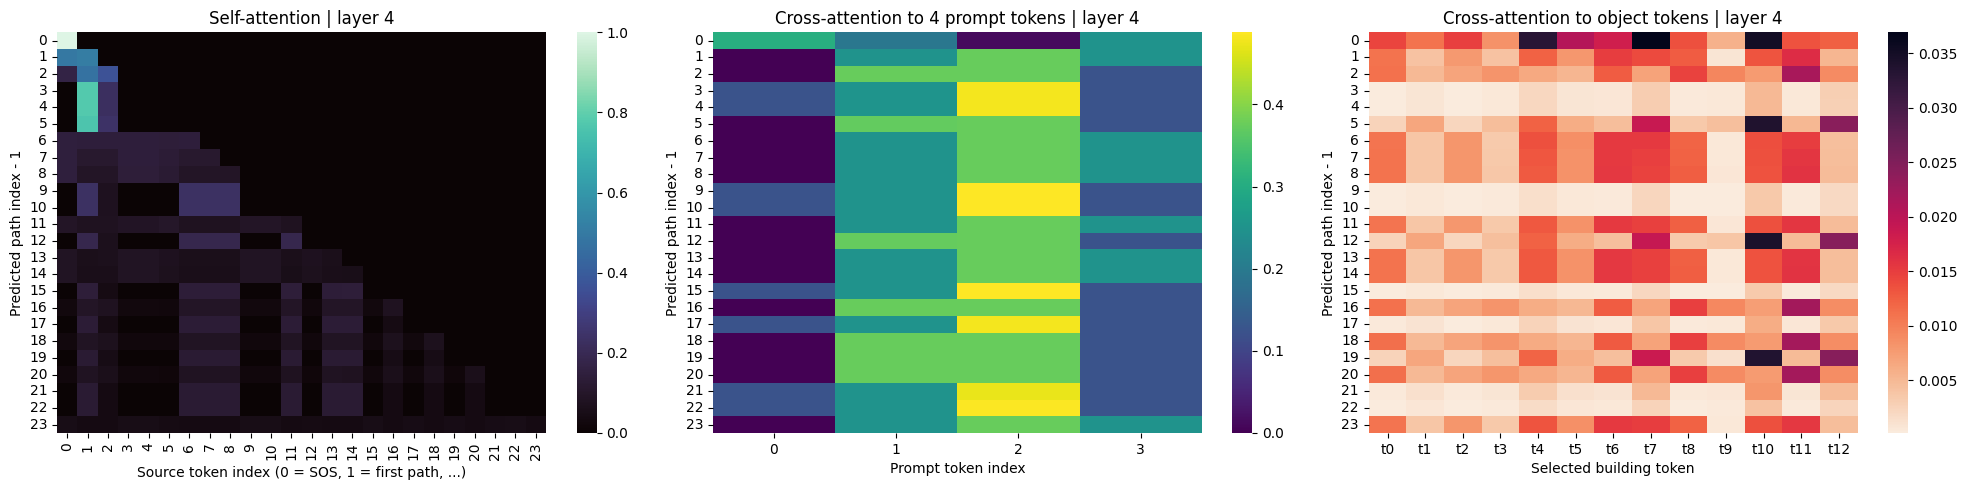

In [ ]:
plot_object_attention_heatmaps(attn_run, object_meta_df, layer_idx=-4) ## line_of_

,token_index,object_index,attention,dist_corr,dist_rx,dist_tx,corridor_progress
2193,9,0,0.039514,22.114223,102.038948,26.221476,0.123918
2195,11,58,0.031453,25.357176,26.200737,110.069534,0.942000
2190,6,182,0.031266,14.007215,14.007215,121.485359,1.000000
2184,0,160,0.027154,5.637236,7.852032,108.384560,0.951929
2192,8,122,0.024777,17.052555,22.142761,101.028419,0.875775
2186,2,102,0.014509,6.540738,24.999811,89.813232,0.787791
2188,4,82,0.013751,10.494250,10.494250,122.047745,1.000000
2191,7,156,0.012944,16.305876,16.305876,126.634323,1.000000


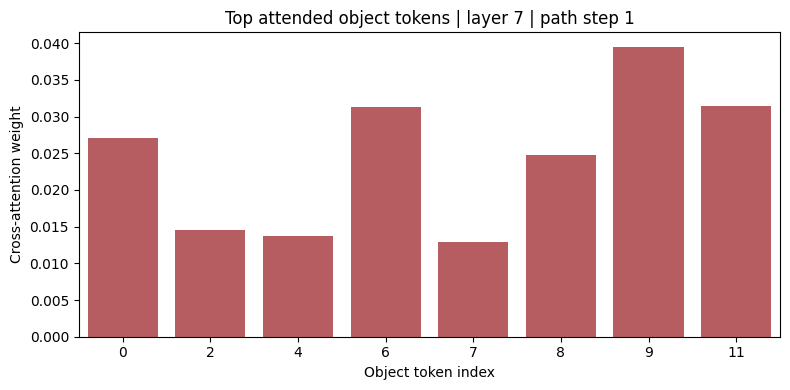

,token_index,object_index,attention,dist_corr,dist_rx,dist_tx,corridor_progress
2232,9,0,0.026354,22.114223,102.038948,26.221476,0.123918
2234,11,58,0.021956,25.357176,26.200737,110.069534,0.942000
2229,6,182,0.021356,14.007215,14.007215,121.485359,1.000000
2223,0,160,0.015175,5.637236,7.852032,108.384560,0.951929
2231,8,122,0.014240,17.052555,22.142761,101.028419,0.875775
2227,4,82,0.007104,10.494250,10.494250,122.047745,1.000000
2230,7,156,0.006432,16.305876,16.305876,126.634323,1.000000
2225,2,102,0.005738,6.540738,24.999811,89.813232,0.787791


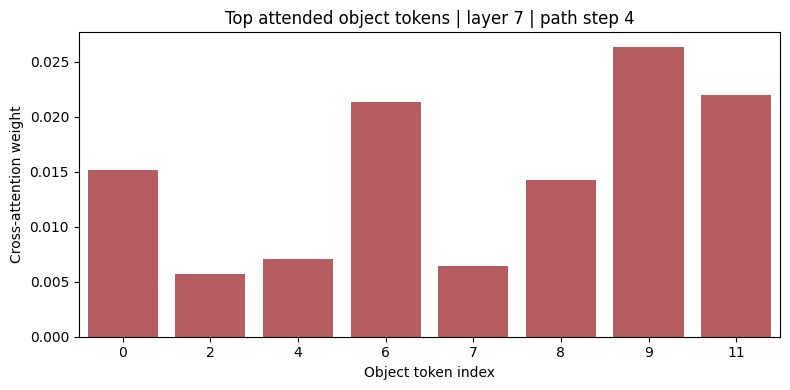

In [12]:
plot_top_objects_for_query(attn_long_df, layer_idx=-1, query_path_index=1, top_k=8)
plot_top_objects_for_query(attn_long_df, layer_idx=-1, query_path_index=min(4, get_gt_num_paths(attn_run['path_lengths'])), top_k=8)

<Axes: title={'center': 'Spatial attention over selected buildings | layer 7 | path step 10 | raw path 9'}, xlabel='x position', ylabel='y position'>

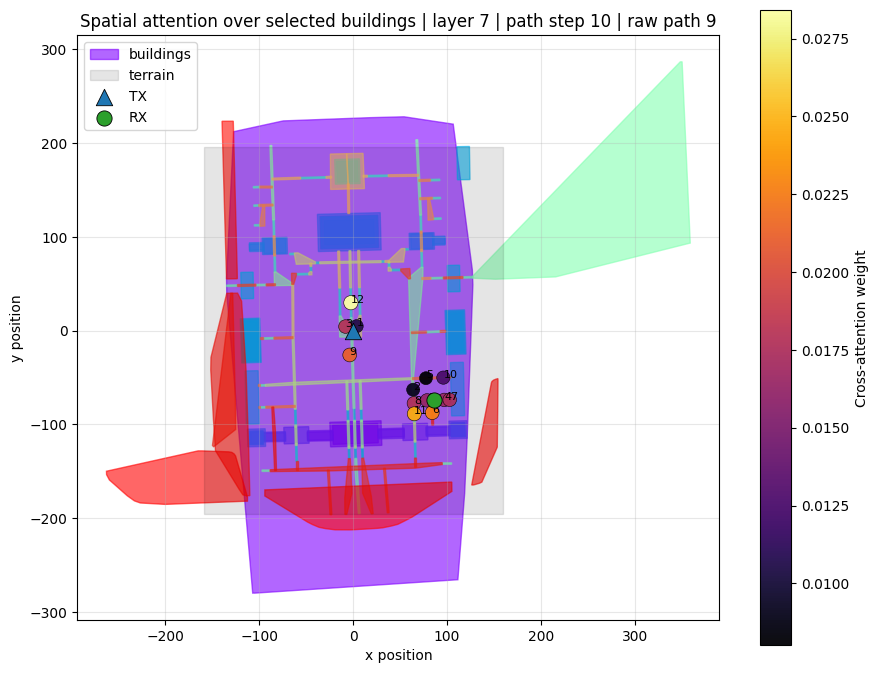

In [ ]:
plot_spatial_attention_map(object_meta_df, attn_long_df, layer_idx=-1, query_path_index=10, overlay_rays=False, show_tx_rx=True)

In [40]:
object_meta_df

,token_index,object_index,center_x,center_y,width,depth,height,footprint_area,volume,dist_tx,dist_rx,dist_corr,corridor_progress,signed_lateral_offset,permittivity,conductivity,scattering_coefficient,corridor_rank,rx_rank,tx_rank
0,0,160,78.802643,-74.392365,28.290230,2.767662,0.0,60.492973,0.000,108.384560,7.852032,5.637236,0.951929,5.637234,5.31,0.08987,0.2,1,1,8
1,1,129,3.767942,4.678156,10.436954,23.051380,0.0,59.664307,0.000,6.054224,114.004257,6.054224,0.000000,-6.052611,5.31,0.08987,0.2,2,11,1
2,2,102,63.993225,-62.998970,3.379955,23.672451,0.0,51.191566,0.000,89.813232,24.999811,6.540738,0.787791,6.540737,5.31,0.08987,0.2,3,7,5
3,3,99,-8.111727,4.289462,13.390369,22.539663,0.0,62.743237,0.000,9.149243,122.661453,9.149243,0.000000,1.934231,5.31,0.08987,0.2,4,12,2
4,4,82,97.108963,-73.896797,8.418571,1.822189,0.0,19.957996,0.000,122.047745,10.494250,10.494250,1.000000,-6.591515,5.31,0.08987,0.2,5,2,12
5,5,161,77.607338,-50.736992,28.679295,2.967625,0.0,61.256031,0.000,92.743591,24.606476,11.618429,0.809234,-11.618427,5.31,0.08987,0.2,6,6,6
6,6,182,84.310257,-87.450104,3.048912,26.473381,0.0,56.829460,0.000,121.485359,14.007215,14.007215,1.000000,12.023994,5.31,0.08987,0.2,7,3,11
7,7,156,102.923523,-73.740875,3.307823,2.088348,0.0,10.508593,0.000,126.634323,16.305876,16.305876,1.000000,-10.474545,5.31,0.08987,0.2,8,4,13
8,8,122,64.813019,-77.487198,2.253967,5.515663,0.0,14.854618,0.000,101.028419,22.142761,17.052555,0.875775,17.052551,5.31,0.08987,0.2,9,5,7
9,9,0,-3.621067,-26.001755,262.496002,507.582977,17.0,1435.321045,2062868.125,26.221476,102.038948,22.114223,0.123918,22.114223,5.31,0.08987,0.2,10,10,3


In [71]:
candidate_indices = rank_samples_by_num_paths(dataset_wrapper, top_k=MAX_AGGREGATE_SAMPLES)['sample_index'].tolist()
summary_attn_df, long_attn_df = aggregate_object_attention_statistics(model, dataset_wrapper, bundle, candidate_indices)
print('summary rows:', len(summary_attn_df), '| long rows:', len(long_attn_df), '| samples:', summary_attn_df['sample_index'].nunique() if not summary_attn_df.empty else 0)
summary_attn_df.head()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:05<00:00, 12.50it/s]

summary rows: 12800 | long rows: 153600 | samples: 64


,layer,query_path_index,prefix_mass,object_mass,object_entropy,top1_object_mass,top3_object_mass,self_first_prev,self_recent_prev,self_dominant_prev,top_object_token_index,top_object_index,top_object_dist_corr,top_object_dist_rx,top_object_corridor_progress,sample_index
0,0,1,0.152055,0.847945,1.594208,0.466516,0.597537,NaN,NaN,NaN,2,0,25.719181,25.719181,1.0,4244
1,0,2,0.431541,0.568459,1.717192,0.075348,0.186070,0.745069,0.745069,0.745069,7,117,56.394978,56.394978,1.0,4244
2,0,3,0.057411,0.942589,2.221600,0.234767,0.445622,0.138849,0.705738,0.138849,2,0,25.719181,25.719181,1.0,4244
3,0,4,0.094439,0.905561,1.864669,0.407562,0.565282,0.142518,0.310258,0.142518,2,0,25.719181,25.719181,1.0,4244
4,0,5,0.081357,0.918643,2.290996,0.144190,0.353529,0.097667,0.265608,0.097667,2,0,25.719181,25.719181,1.0,4244


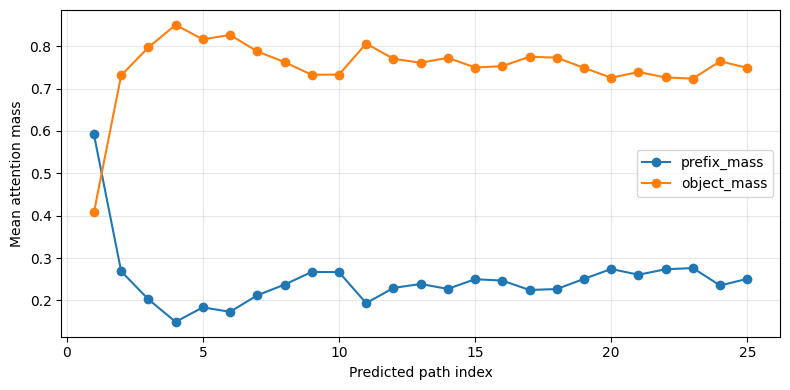

In [38]:
plot_object_attention_summary_curves(summary_attn_df, layer_idx=-2)


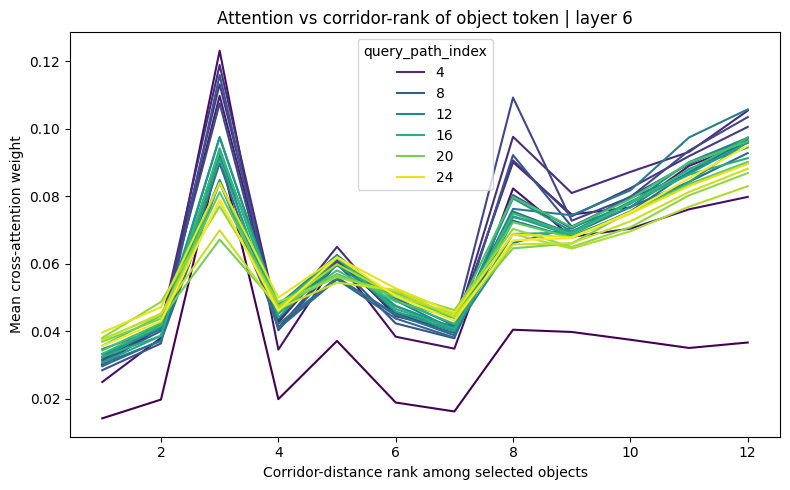

In [16]:
plot_attention_vs_corridor_rank(long_attn_df, layer_idx=-2, max_rank=min(12, MODEL_CONFIG['max_objects']))

In [93]:
high_ranking_non_los = list(set(non_los_idx).intersection(set(candidate_indices)))
high_ranking_los = list(set(los_idx).intersection(set(candidate_indices)))

high_ranking_non_los

[6147,
 7946,
 4244,
 3489,
 6179,
 678,
 2216,
 7720,
 1069,
 7859,
 1204,
 824,
 6331,
 6080,
 4042,
 3531,
 6219,
 8017,
 3158,
 2903,
 5337,
 2399,
 4833,
 8937,
 4849,
 2804,
 6135]

ground-truth number of paths: 25
selected object tokens: 12


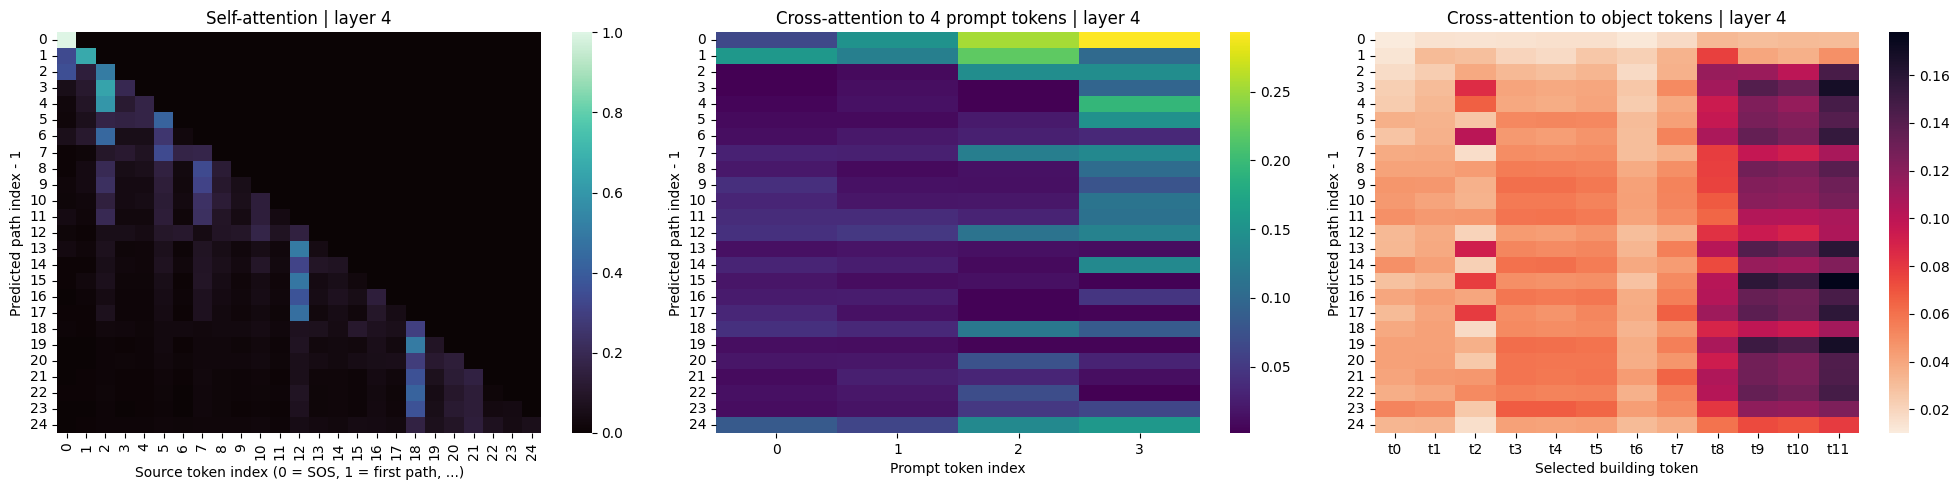

In [100]:
batch = collate_single(dataset_wrapper, high_ranking_non_los[1])
attn_run = run_teacher_forced_attention(model, batch)
object_meta_df = build_object_metadata(bundle, dataset_wrapper, high_ranking_non_los[1])
summary_df = extract_object_attention_rows(attn_run, object_meta_df)
attn_long_df = extract_object_attention_long(attn_run, object_meta_df)

print('ground-truth number of paths:', get_gt_num_paths(attn_run['path_lengths']))
print('selected object tokens:', len(object_meta_df))
plot_object_attention_heatmaps(attn_run, object_meta_df, layer_idx=-4,) ## line_of_

ground-truth number of paths: 25
selected object tokens: 12


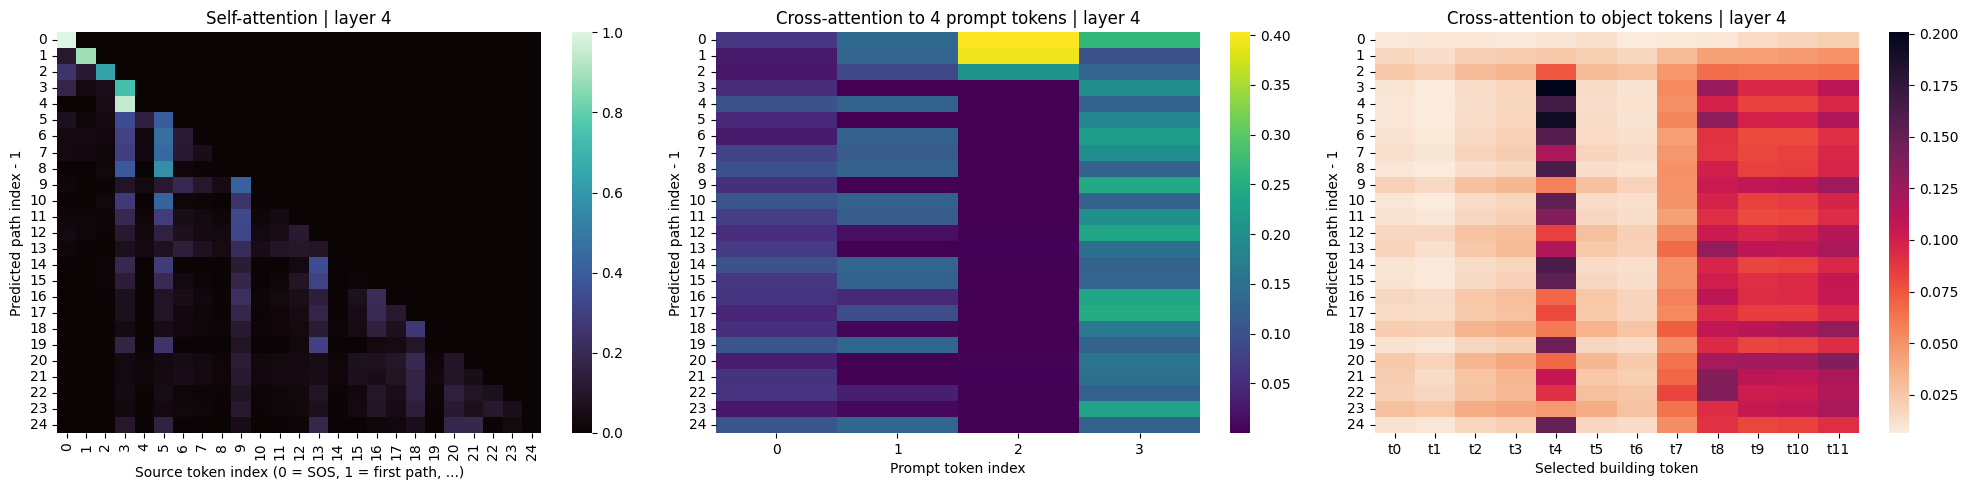

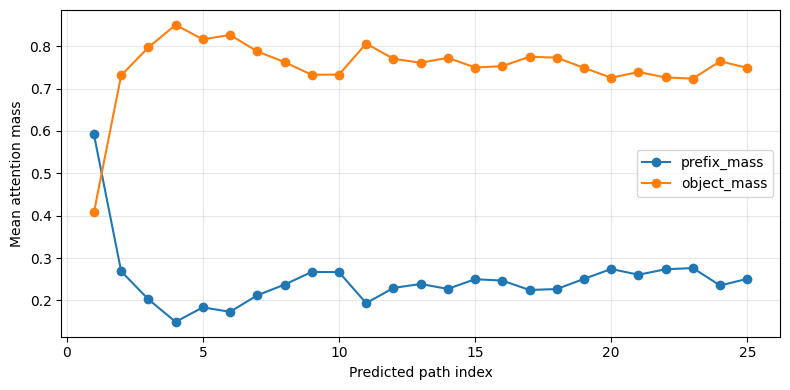

In [102]:
batch = collate_single(dataset_wrapper, high_ranking_los[1])
attn_run = run_teacher_forced_attention(model, batch)
object_meta_df = build_object_metadata(bundle, dataset_wrapper, high_ranking_los[1])
summary_df = extract_object_attention_rows(attn_run, object_meta_df)
attn_long_df = extract_object_attention_long(attn_run, object_meta_df)

print('ground-truth number of paths:', get_gt_num_paths(attn_run['path_lengths']))
print('selected object tokens:', len(object_meta_df))
plot_object_attention_heatmaps(attn_run, object_meta_df, layer_idx=-4,) ## line_of_
plot_object_attention_summary_curves(summary_attn_df, layer_idx=-2)

In [87]:
attn_run['cross_attn'].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

## How to turn this into a paper figure

The strongest paper-ready options are usually:

1. **Single-sample object-token heatmap**
   - Use the last decoder layer.
   - Pick a sample with many valid paths.
   - Show that early path steps attend strongly to a small set of corridor-relevant buildings.

2. **Aggregate attention vs corridor-rank curve**
   - If lower corridor-rank objects receive higher average attention, that supports the claim that the object-token model uses spatially relevant structures.

3. **Attention concentration across path steps**
   - If `top1_object_mass` or `top3_object_mass` is high for early steps and more diffuse later, that supports the intuition that the earliest dominant paths rely on a smaller set of key structures.

### Safe paper wording

A safe interpretation would be:

> "The object-token attention patterns are consistent with PathFormer relying on a small subset of geometrically relevant buildings, especially for early and dominant paths, while later path predictions distribute attention more broadly across the selected scene context."